# Low-Rank Factorization via SVD — Teori & Implementasi

## Konsep Matematis

Singular Value Decomposition memecah matriks bobot W menjadi:

$$W = U \Sigma V^T$$

Dimana untuk Dense layer (200,704 × 16):
- **U**: left singular vectors (200,704 × 16)
- **Σ**: diagonal singular values σ₁ ≥ σ₂ ≥ ... ≥ σ₁₆
- **V^T**: right singular vectors (16 × 16)

## Truncation ke Rank r

Dengan mengambil hanya r singular value terbesar:

$$W \approx W_r = U_r \Sigma_r V_r^T$$

Error truncation = √(σ²ᵣ₊₁ + ... + σ²₁₆) — semakin kecil σ yang dibuang, semakin kecil error.

## Balanced Scaling (Numerical Stability)

Singular values dibagi merata ke kedua sisi:

$$W_1 = U_r \sqrt{\Sigma_r}, \quad W_2 = \sqrt{\Sigma_r} V_r^T$$

## Implementasi di Neural Network

Satu Dense(16) diganti dengan dua Dense layer berurutan:

```
Dense(200704 → 16)  ───►  Dense(200704 → r, no_bias) → Dense(r → 16, with_bias)
```

## Reduksi Parameter

| Layout | Parameter |
|---|---|
| Original Dense(16) | 200,704 × 16 + 16 = 3,211,280 |
| Low-rank (r=4) | 200,704 × 4 + 4 × 16 + 16 = 802,896 |
| **Reduksi** | **3.85× lebih sedikit** |

## Catatan

Penelitian ini menggunakan **SVD standar** (`np.linalg.svd`), bukan Randomized Subspace Iteration (RSI), karena dimensi matriks (200,704 × 16) tidak terlalu besar untuk SVD eksak dan tidak menunjukkan slow spectral decay yang membutuhkan RSI.


In [1]:
import os, time, gzip, shutil, json
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                                     GlobalAveragePooling2D, Reshape, Multiply, Input)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ----------------------------------------------------------------------------
# Custom ChannelAttention layer (must be identical to training.ipynb so that
# the saved .keras model can be loaded back successfully).
# ----------------------------------------------------------------------------
class ChannelAttention(Layer):
    """Channel Attention Module — same as used in training."""
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels      = input_shape[-1]
        self.gap      = GlobalAveragePooling2D()
        self.dense1   = Dense(max(1, channels // self.ratio), activation="relu")
        self.dense2   = Dense(channels, activation="sigmoid")
        self.reshape  = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}


In [2]:
import random, os
import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print(f"[INFO] enable_op_determinism: {e}")

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try: tf.config.experimental.set_memory_growth(g, True)
        except RuntimeError as e: print(f"[GPU] memory growth: {e}")
    print(f"GPU detected: {[g.name for g in gpus]}")
else:
    print("Running on CPU.")

# ---------------------------------------------------------------------------
# Inference batch size — kept small to avoid GPU OOM on the 200,704×16 Dense
# layer in this model. Increase this if your GPU has plenty of memory.
# Setting USE_CPU_FOR_INFERENCE=True will hide the GPU from TensorFlow if
# you keep hitting OOM errors.
# ---------------------------------------------------------------------------
INFER_BATCH_SIZE      = 8
USE_CPU_FOR_INFERENCE = False
if USE_CPU_FOR_INFERENCE and gpus:
    try:
        tf.config.set_visible_devices([], "GPU")
        print("[INFO] GPU hidden — running inference on CPU.")
    except RuntimeError as e:
        print(f"[INFO] could not hide GPU: {e}")


TensorFlow version: 2.21.0
Running on CPU.


In [3]:
# ============================================================================
# UNIFIED EVALUATION HELPERS  (same definitions across all 4 notebooks)
# ============================================================================

def get_file_size_kb(path):
    """File size in KB, or 0.0 if missing."""
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0

def fmt_size(kb):
    if kb < 1024: return f"{kb:.2f} KB"
    return f"{kb/1024:.2f} MB"

def evaluate_pipeline(extractor, svm_clf, scaler, X_test, y_test_int,
                      class_names, label="Model", warmup=True):
    """Runs feature extraction + scaling + SVM prediction.
    Returns a dict containing accuracy, sensitivity, specificity, F1, AUC,
    confusion matrix, feature-extraction time, inference time."""

    # warm-up so first-call graph compilation does not pollute timing
    if warmup:
        try:
            _ = extractor.predict(X_test[:2], verbose=0)
        except Exception:
            pass

    # ---- timing: feature extraction ----
    t0 = time.perf_counter()
    X_test_feat = extractor.predict(X_test, verbose=0)
    feat_time = time.perf_counter() - t0

    # ---- timing: scaling + SVM inference ----
    t0 = time.perf_counter()
    X_test_scaled = scaler.transform(X_test_feat)
    y_pred        = svm_clf.predict(X_test_scaled)
    y_pred_proba  = svm_clf.predict_proba(X_test_scaled)
    inf_time      = time.perf_counter() - t0

    n_classes = len(class_names)
    cm        = confusion_matrix(y_test_int, y_pred, labels=list(range(n_classes)))

    sens, spec, prec, f1s = [], [], [], []
    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        s  = TP/(TP+FN) if (TP+FN)>0 else 0.0
        sp = TN/(TN+FP) if (TN+FP)>0 else 0.0
        p  = TP/(TP+FP) if (TP+FP)>0 else 0.0
        f  = 2*p*s/(p+s) if (p+s)>0 else 0.0
        sens.append(s); spec.append(sp); prec.append(p); f1s.append(f)

    y_test_bin   = label_binarize(y_test_int, classes=list(range(n_classes)))
    auc_per_cls  = roc_auc_score(y_test_bin, y_pred_proba, average=None , multi_class="ovr")
    auc_macro    = roc_auc_score(y_test_bin, y_pred_proba, average="macro", multi_class="ovr")
    auc_micro    = roc_auc_score(y_test_bin, y_pred_proba, average="micro", multi_class="ovr")
    accuracy     = accuracy_score(y_test_int, y_pred)

    return {
        "label"        : label,
        "accuracy"     : accuracy,
        "sensitivity"  : list(sens),
        "specificity"  : list(spec),
        "precision"    : list(prec),
        "f1"           : list(f1s),
        "auc_per_class": list(auc_per_cls),
        "auc_macro"    : auc_macro,
        "auc_micro"    : auc_micro,
        "cm"           : cm,
        "feat_time"    : feat_time,
        "inf_time"     : inf_time,
        "y_pred"       : y_pred,
        "y_pred_proba" : y_pred_proba,
    }


def per_class_metrics_df(metrics, class_names):
    rows = []
    rows.append(["Sensitivity"] + [f"{v:.4f}" for v in metrics["sensitivity" ]] + [f'{np.mean(metrics["sensitivity" ]):.4f}'])
    rows.append(["Specificity"] + [f"{v:.4f}" for v in metrics["specificity" ]] + [f'{np.mean(metrics["specificity" ]):.4f}'])
    rows.append(["Precision"  ] + [f"{v:.4f}" for v in metrics["precision"   ]] + [f'{np.mean(metrics["precision"   ]):.4f}'])
    rows.append(["F1-Score"   ] + [f"{v:.4f}" for v in metrics["f1"          ]] + [f'{np.mean(metrics["f1"          ]):.4f}'])
    rows.append(["AUC"        ] + [f"{v:.4f}" for v in metrics["auc_per_class"]] + [f'{np.mean(metrics["auc_per_class"]):.4f}'])
    return pd.DataFrame(rows, columns=["Metric"] + class_names + ["Mean"])


def print_evaluation_block(metrics, class_names, title="EVALUATION METRICS"):
    print("=" * 78)
    print(f"  {title} — {metrics['label']}")
    print("=" * 78)
    df = per_class_metrics_df(metrics, class_names)
    print(df.to_string(index=False))
    print("-" * 78)
    print(f"Accuracy        : {metrics['accuracy' ]:.4f}")
    print(f"AUC (macro avg) : {metrics['auc_macro']:.4f}")
    print(f"AUC (micro avg) : {metrics['auc_micro']:.4f}")
    print("\nConfusion Matrix (rows=true, cols=pred):")
    cm_df = pd.DataFrame(metrics["cm"], index=class_names, columns=class_names)
    print(cm_df.to_string())
    print("=" * 78)


def resource_table(name_size_param_list):
    """Builds a resource-comparison table.
    Each entry: (label, size_kb, n_params, feat_time_s, inf_time_s)"""
    df = pd.DataFrame(
        name_size_param_list,
        columns=["Model", "Size (KB)", "Parameters",
                 "Feature Extraction (s)", "Inference (s)"]
    )
    return df


def plot_confusion_matrix(metrics, class_names, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title or f"Confusion Matrix — {metrics['label']}")
    return ax


In [4]:
# ============================================================================
# LOAD DATASET (train / valid / test)
# ============================================================================
dataset_base_path = "../dataset_processed2"
img_size          = 224
categories        = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names       = ["Bengin", "Malignant", "Normal"]
num_classes       = len(categories)

def load_split_data(split_path, categories):
    X, y = [], []
    for class_idx, cat in enumerate(categories):
        cat_path = os.path.join(split_path, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0
            X.append(img); y.append(class_idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading dataset…")
X_train, y_train_labels = load_split_data(os.path.join(dataset_base_path, "train"), categories)
X_valid, y_valid_labels = load_split_data(os.path.join(dataset_base_path, "valid"), categories)
X_test , y_test_labels  = load_split_data(os.path.join(dataset_base_path, "test" ), categories)

y_train     = to_categorical(y_train_labels, num_classes=num_classes)
y_valid     = to_categorical(y_valid_labels, num_classes=num_classes)
y_test      = to_categorical(y_test_labels , num_classes=num_classes)
y_train_int = y_train_labels
y_valid_int = y_valid_labels
y_test_int  = y_test_labels

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")


Loading dataset…
Train: (737, 224, 224, 3), Valid: (158, 224, 224, 3), Test: (159, 224, 224, 3)


In [ ]:
# ============================================================================
# LOAD ORIGINAL ARTEFACTS  (saved by training.ipynb)
# ============================================================================
ORIG_FOLDER = "saved_models_original"

if not os.path.isdir(ORIG_FOLDER):
    raise FileNotFoundError(
        f"Folder '{ORIG_FOLDER}' tidak ditemukan. "
        "Jalankan training.ipynb lebih dulu agar model & artefak tersimpan."
    )

cnn_path       = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
extractor_path = os.path.join(ORIG_FOLDER, "feature_extractor.keras")
svm_path       = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
scaler_path    = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")

print(f"Loading artefacts from {ORIG_FOLDER}/ …")
model_orig     = tf.keras.models.load_model(cnn_path, custom_objects=CUSTOM_OBJECTS)
extractor_orig = tf.keras.models.load_model(extractor_path, custom_objects=CUSTOM_OBJECTS)
svm_orig       = joblib.load(svm_path)
scaler_orig    = joblib.load(scaler_path)

orig_size_cnn       = get_file_size_kb(cnn_path)
orig_size_extractor = get_file_size_kb(extractor_path)
orig_size_svm       = get_file_size_kb(svm_path)
orig_size_scaler    = get_file_size_kb(scaler_path)

# Tabel ukuran artefak yang di-load
size_load_df = pd.DataFrame([
    ["cnn_attention_model.keras", orig_size_cnn      , get_file_size_kb(cnn_path      )],
    ["feature_extractor.keras"  , orig_size_extractor, get_file_size_kb(extractor_path)],
    ["svm_classifier.pkl"       , orig_size_svm      , get_file_size_kb(svm_path      )],
    ["feature_scaler.pkl"       , orig_size_scaler   , get_file_size_kb(scaler_path   )],
], columns=["File", "Size (KB)", "Bytes/1024"])
print("\nLoaded artefact sizes:")
print(size_load_df.to_string(index=False))
print(f"\nCNN params         : {model_orig.count_params():,}")
print(f"Extractor params   : {extractor_orig.count_params():,}")


In [6]:
# ============================================================================
# LOW-RANK DECOMPOSITION HELPERS
# ============================================================================
def _gzip_file(src, dst):
    with open(src, "rb") as fi, gzip.open(dst, "wb") as fo:
        shutil.copyfileobj(fi, fo)

def svd_lowrank_dense(W, b, rank):
    """SVD-decompose a Dense weight W (in_dim, out_dim) into two matrices.
    Returns (W1, W2) such that  W ≈ W1 @ W2  with W1 (in_dim, r), W2 (r, out_dim)."""
    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    r  = max(1, min(rank, len(S)))
    W1 = U[:, :r] * np.sqrt(S[:r])
    W2 = (np.sqrt(S[:r])[:, None]) * Vt[:r, :]
    return W1.astype(np.float32), W2.astype(np.float32), b.astype(np.float32)


def build_lowrank_model(orig_model, num_classes, feature_rank=4):
    """Clone original model up to feature_layer, then replace with low-rank decomposition."""
    # Clone input
    inputs = orig_model.input
    
    # Find the last layer before feature_layer (should be Flatten)
    x = inputs
    for layer in orig_model.layers[1:]:  # skip input layer
        if layer.name == "feature_layer":
            break
        x = layer(x)
    
    # Add low-rank Dense replacement
    x_low    = Dense(feature_rank, activation=None, use_bias=False, name="feature_lowrank")(x)
    features = Dense(16, activation="relu", name="feature_layer")(x_low)
    output   = Dense(num_classes, activation="softmax", name="softmax_output")(features)
    
    return Model(inputs, output, name="CNN_Attention_LowRank")


def transfer_weights_with_lowrank(orig_model, lowrank_model, feature_rank=4):
    """Copy weights from orig_model into lowrank_model and SVD-decompose the
    feature_layer's Dense kernel."""
    name_to_orig = {l.name: l for l in orig_model.layers}
    name_to_low  = {l.name: l for l in lowrank_model.layers}

    # 1) copy all layers that are unchanged (Conv + Attention + Flatten)
    for name, lr_layer in name_to_low.items():
        if name in name_to_orig and name not in ("feature_layer", "feature_lowrank", "softmax_output"):
            try:
                orig_weights = name_to_orig[name].get_weights()
                if orig_weights:  # only set if layer has weights
                    lr_layer.set_weights(orig_weights)
            except Exception as e:
                print(f"[INFO] Could not copy weights for {name}: {e}")

    # 2) decompose original feature_layer Dense
    try:
        W, b = name_to_orig["feature_layer"].get_weights()
        print(f"[DEBUG] Original feature_layer shape: W={W.shape}, b={b.shape}")
        
        W1, W2, b_new = svd_lowrank_dense(W, b, feature_rank)
        print(f"[DEBUG] After SVD: W1={W1.shape}, W2={W2.shape}")
        
        name_to_low["feature_lowrank"].set_weights([W1])
        name_to_low["feature_layer"  ].set_weights([W2, b_new])
    except Exception as e:
        print(f"[ERROR] Failed to transfer weights: {e}")
        raise
    
    return lowrank_model


def setup_lowrank_pipeline(model, X_train, X_valid, y_train, y_valid,
                           feature_rank=4, finetune_epochs=5, batch_size=32):
    os.makedirs("artifacts", exist_ok=True)
    num_classes = y_train.shape[1]

    lowrank_model = build_lowrank_model(model, num_classes, feature_rank=feature_rank)
    lowrank_model = transfer_weights_with_lowrank(model, lowrank_model, feature_rank=feature_rank)
    lowrank_model.compile(optimizer="adam", loss="categorical_crossentropy",
                          metrics=["accuracy"])

    # short fine-tune to recover any accuracy lost in SVD
    t0 = time.perf_counter()
    hist = lowrank_model.fit(
        X_train, y_train, epochs=finetune_epochs, batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[EarlyStopping(patience=2, monitor="val_loss",
                                 restore_best_weights=True)],
        verbose=1,
    )
    finetune_time = time.perf_counter() - t0

    extractor_lr = Model(inputs=lowrank_model.input,
                         outputs=lowrank_model.get_layer("feature_layer").output)

    cnn_lr_path  = "artifacts/cnn_attention_lowrank.keras"
    ext_lr_path  = "artifacts/feature_extractor_lowrank.keras"
    cnn_lr_gz    = "artifacts/cnn_attention_lowrank.keras.gz"
    ext_lr_gz    = "artifacts/feature_extractor_lowrank.keras.gz"
    lowrank_model.save(cnn_lr_path)
    extractor_lr .save(ext_lr_path)
    _gzip_file(cnn_lr_path, cnn_lr_gz)
    _gzip_file(ext_lr_path, ext_lr_gz)

    paths = dict(cnn=cnn_lr_path, extractor=ext_lr_path,
                 cnn_gz=cnn_lr_gz, extractor_gz=ext_lr_gz)
    return paths, lowrank_model, extractor_lr, hist, finetune_time

In [7]:
# ============================================================================
# PIPELINE A: ORIGINAL  (no retraining — uses loaded SVM + scaler)
# ============================================================================
metrics_orig = evaluate_pipeline(
    extractor_orig, svm_orig, scaler_orig,
    X_test, y_test_int, class_names, label="Original (loaded)"
)
print_evaluation_block(metrics_orig, class_names, "ORIGINAL — TEST SET")

# ============================================================================
# PIPELINE B: LOW-RANK MODELS — MULTI-RANK COMPARISON
# ============================================================================
ranks_to_test = [2, 4, 6, 8, 12]
models_by_rank = {}
extractors_by_rank = {}
metrics_by_rank = {}
paths_by_rank = {}
times_by_rank = {}

print("\n" + "=" * 78)
print("TESTING MULTIPLE RANKS FOR LOW-RANK SVD DECOMPOSITION…")
print("=" * 78)

for rank in ranks_to_test:
    print(f"\n>>> Processing rank = {rank} …")
    
    paths_lr, model_lr, extractor_lr, hist_lr, lr_time = setup_lowrank_pipeline(
        model_orig, X_train, X_valid, y_train, y_valid,
        feature_rank=rank, finetune_epochs=5, batch_size=32,
    )
    
    models_by_rank[rank] = model_lr
    extractors_by_rank[rank] = extractor_lr
    paths_by_rank[rank] = paths_lr
    times_by_rank[rank] = lr_time
    
    print(f"[Rank {rank}] fine-tune time: {lr_time:.3f} s")
    
    # Refit SVM + scaler on features from this rank's CNN
    X_tr_l = extractor_lr.predict(X_train, batch_size=INFER_BATCH_SIZE, verbose=0)
    X_va_l = extractor_lr.predict(X_valid, batch_size=INFER_BATCH_SIZE, verbose=0)
    
    scaler_lr = StandardScaler().fit(np.vstack([X_tr_l, X_va_l]))
    X_tr_ls   = scaler_lr.transform(X_tr_l)
    X_va_ls   = scaler_lr.transform(X_va_l)
    
    svm_lr = SVC(kernel="rbf", C=1.0, gamma="scale",
                 probability=True, random_state=42)
    svm_lr.fit(np.vstack([X_tr_ls, X_va_ls]),
               np.concatenate([y_train_int, y_valid_int]))
    
    joblib.dump(svm_lr   , f"artifacts/svm_lowrank_r{rank}.pkl")
    joblib.dump(scaler_lr, f"artifacts/scaler_lowrank_r{rank}.pkl")
    
    # Evaluate this rank
    metrics = evaluate_pipeline(
        extractor_lr, svm_lr, scaler_lr,
        X_test, y_test_int, class_names, label=f"Low-Rank (rank={rank})"
    )
    metrics_by_rank[rank] = metrics
    print_evaluation_block(metrics, class_names, f"LOW-RANK RANK={rank} — TEST SET")    

  ORIGINAL — TEST SET — Original (loaded)
     Metric Bengin Malignant Normal   Mean
Sensitivity 1.0000    1.0000 0.9836 0.9945
Specificity 0.9930    1.0000 1.0000 0.9977
  Precision 0.9412    1.0000 1.0000 0.9804
   F1-Score 0.9697    1.0000 0.9917 0.9871
        AUC 1.0000    1.0000 1.0000 1.0000
------------------------------------------------------------------------------
Accuracy        : 0.9937
AUC (macro avg) : 1.0000
AUC (micro avg) : 1.0000

Confusion Matrix (rows=true, cols=pred):
           Bengin  Malignant  Normal
Bengin         16          0       0
Malignant       0         82       0
Normal          1          0      60

TESTING MULTIPLE RANKS FOR LOW-RANK SVD DECOMPOSITION…

>>> Processing rank = 2 …
[DEBUG] Original feature_layer shape: W=(100352, 16), b=(16,)
[DEBUG] After SVD: W1=(100352, 2), W2=(2, 16)
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 740ms/step - accuracy: 0.6174 - loss: 1.0983 - val_accuracy: 0.7215 - val_loss: 0.6387
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 

Dense bottleneck shape: (100352, 16)  (1,605,632 params)
Total singular values: 16

SINGULAR VALUE SPECTRUM & ENERGY ANALYSIS
 Idx         Sigma    Normalized    Cum. Energy      Selected
--------------------------------------------------------------------------------
   1       18.2423        1.0000        46.18%  [2, 4, 6, 8, 12]
   2       14.6692        0.8041        76.05%  [2, 4, 6, 8, 12]
   3        6.5705        0.3602        82.04%  [4, 6, 8, 12]
   4        5.8985        0.3233        86.87%  [4, 6, 8, 12]
   5        5.3448        0.2930        90.83%    [6, 8, 12]
   6        4.2058        0.2306        93.29%    [6, 8, 12]
   7        3.3680        0.1846        94.86%       [8, 12]
   8        2.9761        0.1631        96.09%       [8, 12]
   9        2.5834        0.1416        97.02%          [12]
  10        2.1589        0.1183        97.66%          [12]
  11        2.0655        0.1132        98.26%          [12]
  12        1.9723        0.1081        98.80%    

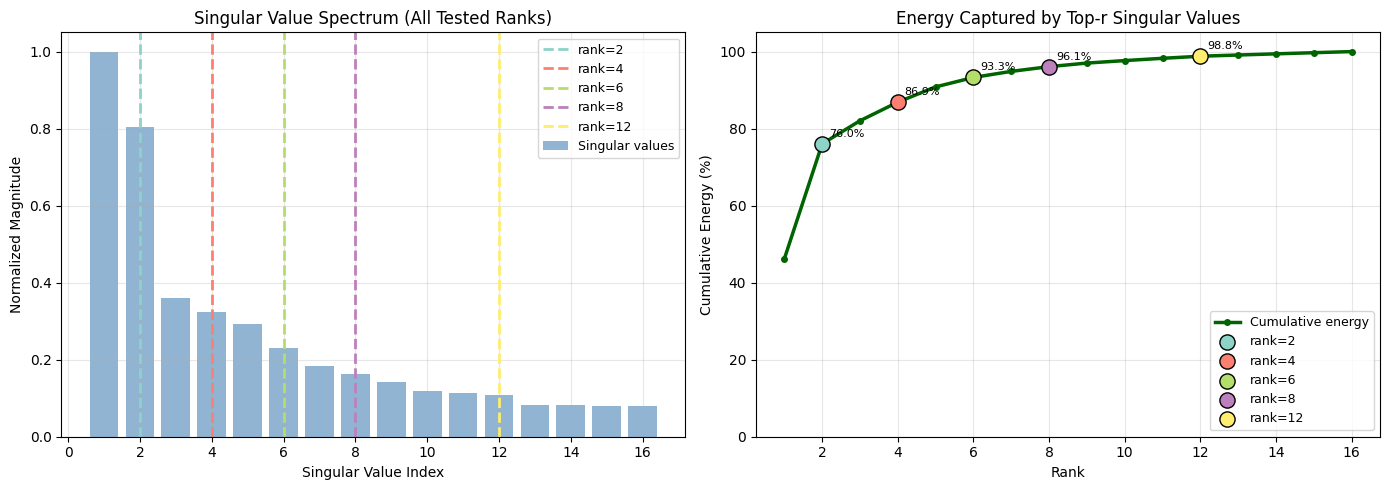


PARAMETER REDUCTION BY RANK
   Model       Structure  Parameters Reduction    Savings
Original       100352x16     1605648     1.00x          -
  Rank=2   100352x2→2x16      200752     8.00x -1,404,896
  Rank=4   100352x4→4x16      401488     4.00x -1,204,160
  Rank=6   100352x6→6x16      602224     2.67x -1,003,424
  Rank=8   100352x8→8x16      802960     2.00x   -802,688
 Rank=12 100352x12→12x16     1204432     1.33x   -401,216


In [11]:
# ============================================================================
# SVD ANALYSIS — Singular Value Spectrum & Reconstruction Error (Multi-Rank)
# ============================================================================
# Re-extract bobot Dense besar dari original model untuk analisis
W_orig_dense, b_orig_dense = (
    model_orig.get_layer("feature_layer").get_weights()
)
print(f"Dense bottleneck shape: {W_orig_dense.shape}  ({np.prod(W_orig_dense.shape):,} params)")

# Lakukan SVD lengkap
U_full, S_full, Vt_full = np.linalg.svd(W_orig_dense, full_matrices=False)
print(f"Total singular values: {len(S_full)}")

# Normalize & cumulative energy
S_norm           = S_full / S_full[0]
cumulative_energy = np.cumsum(S_full**2) / np.sum(S_full**2)

# Display top singular values with all tested ranks
print("\n" + "=" * 80)
print("SINGULAR VALUE SPECTRUM & ENERGY ANALYSIS")
print("=" * 80)
print(f"{'Idx':>4}  {'Sigma':>12}  {'Normalized':>12}  {'Cum. Energy':>13}  {'Selected':>12}")
print("-" * 80)
for i in range(min(16, len(S_full))):
    selected_ranks = [r for r in ranks_to_test if i < r]
    marker = f"{selected_ranks}" if selected_ranks else "-"
    print(f"{i+1:>4}  {S_full[i]:>12.4f}  {S_norm[i]:>12.4f}  "
          f"{cumulative_energy[i]*100:>11.2f}%  {str(marker):>12}")
if len(S_full) > 16:
    print(f"...   ({len(S_full)-16} more)")

# Energy & reconstruction error for each rank
print("\n" + "=" * 80)
print("RECONSTRUCTION ERROR BY RANK")
print("=" * 80)
energy_data = []
for rank in ranks_to_test:
    energy_captured = cumulative_energy[rank-1] * 100
    energy_lost     = 100 - energy_captured
    
    W1_trunc = U_full[:, :rank] * np.sqrt(S_full[:rank])
    W2_trunc = (np.sqrt(S_full[:rank])[:, None]) * Vt_full[:rank, :]
    W_recon  = W1_trunc @ W2_trunc
    recon_err_rel = np.linalg.norm(W_orig_dense - W_recon, "fro") / np.linalg.norm(W_orig_dense, "fro")
    
    energy_data.append([rank, f"{energy_captured:.2f}%", f"{energy_lost:.2f}%", f"{recon_err_rel*100:.4f}%"])
    print(f"Rank {rank:2d}: Energy captured={energy_captured:6.2f}%, "
          f"Energy lost={energy_lost:5.2f}%, Reconstruction error={recon_err_rel*100:6.4f}%")

energy_df = pd.DataFrame(energy_data, columns=["Rank", "Energy Captured", "Energy Lost", "Recon Error %"])

# Plot SV spectrum with all ranks marked
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Spectrum with rank lines
ax1.bar(range(1, len(S_full)+1), S_norm, color="steelblue", alpha=0.6, label="Singular values")
colors_rank = plt.cm.Set3(np.linspace(0, 1, len(ranks_to_test)))
for i, (rank, color) in enumerate(zip(ranks_to_test, colors_rank)):
    ax1.axvline(rank, color=color, linestyle="--", linewidth=2, label=f"rank={rank}")
ax1.set_xlabel("Singular Value Index"); ax1.set_ylabel("Normalized Magnitude")
ax1.set_title("Singular Value Spectrum (All Tested Ranks)"); ax1.legend(loc="upper right", fontsize=9); ax1.grid(alpha=0.3)

# Cumulative energy with rank markers
ax2.plot(range(1, len(S_full)+1), cumulative_energy * 100, 
         marker="o", color="darkgreen", linewidth=2.5, markersize=4, label="Cumulative energy")
for rank, color in zip(ranks_to_test, colors_rank):
    energy_at_rank = cumulative_energy[rank-1] * 100
    ax2.scatter([rank], [energy_at_rank], s=120, color=color, edgecolors="black", zorder=5, label=f"rank={rank}")
    ax2.annotate(f"{energy_at_rank:.1f}%", xy=(rank, energy_at_rank), xytext=(5, 5), 
                textcoords="offset points", fontsize=8)
ax2.set_xlabel("Rank"); ax2.set_ylabel("Cumulative Energy (%)")
ax2.set_title("Energy Captured by Top-r Singular Values")
ax2.legend(loc="lower right", fontsize=9); ax2.grid(alpha=0.3); ax2.set_ylim([0, 105])
plt.tight_layout(); plt.show()

# Parameter breakdown for all ranks
C, D = W_orig_dense.shape
params_orig = C * D + D
print("\n" + "=" * 80)
print("PARAMETER REDUCTION BY RANK")
print("=" * 80)
params_data = [["Original", f"{C}x{D}", params_orig, "1.00x", "-"]]
for rank in ranks_to_test:
    params_lr = C * rank + rank * D + D
    reduction = params_orig / params_lr
    savings = params_orig - params_lr
    params_data.append([f"Rank={rank}", f"{C}x{rank}→{rank}x{D}", params_lr, f"{reduction:.2f}x", f"-{savings:,}"])
param_df = pd.DataFrame(params_data, columns=["Model", "Structure", "Parameters", "Reduction", "Savings"])
print(param_df.to_string(index=False))



RESOURCE COMPARISON (ALL RANKS)
                 Model    Size (KB)  Parameters  Feature Extraction (s)  Inference (s)
              Original 19155.976562     1627343                1.153353       0.002122
 Low-Rank r=2 (.keras) 14453.969727      222447                0.941240       0.001732
 Low-Rank r=4 (.keras) 14454.938477      423183                0.947136       0.001820
 Low-Rank r=6 (.keras) 14453.329102      623919                0.959079       0.001715
 Low-Rank r=8 (.keras) 14454.782227      824655                0.977424       0.002489
Low-Rank r=12 (.keras) 14450.454102     1226127                0.992439       0.001796

ACCURACY vs COMPRESSION TRADE-OFF
   Model Compression Accuracy AUC (macro) Feature Extract Time (s)
Original       1.00x   0.9937      1.0000                   1.1534
  Rank 2       7.32x   0.9874      0.9995                   0.9412
  Rank 4       3.85x   1.0000      1.0000                   0.9471
  Rank 6       2.61x   0.9937      0.9981              

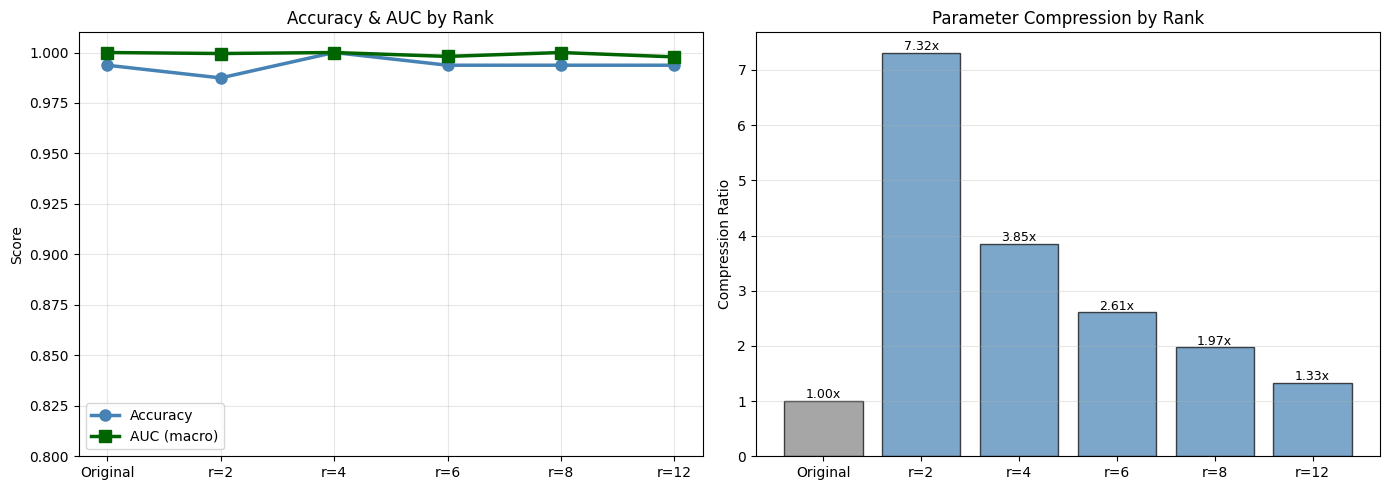

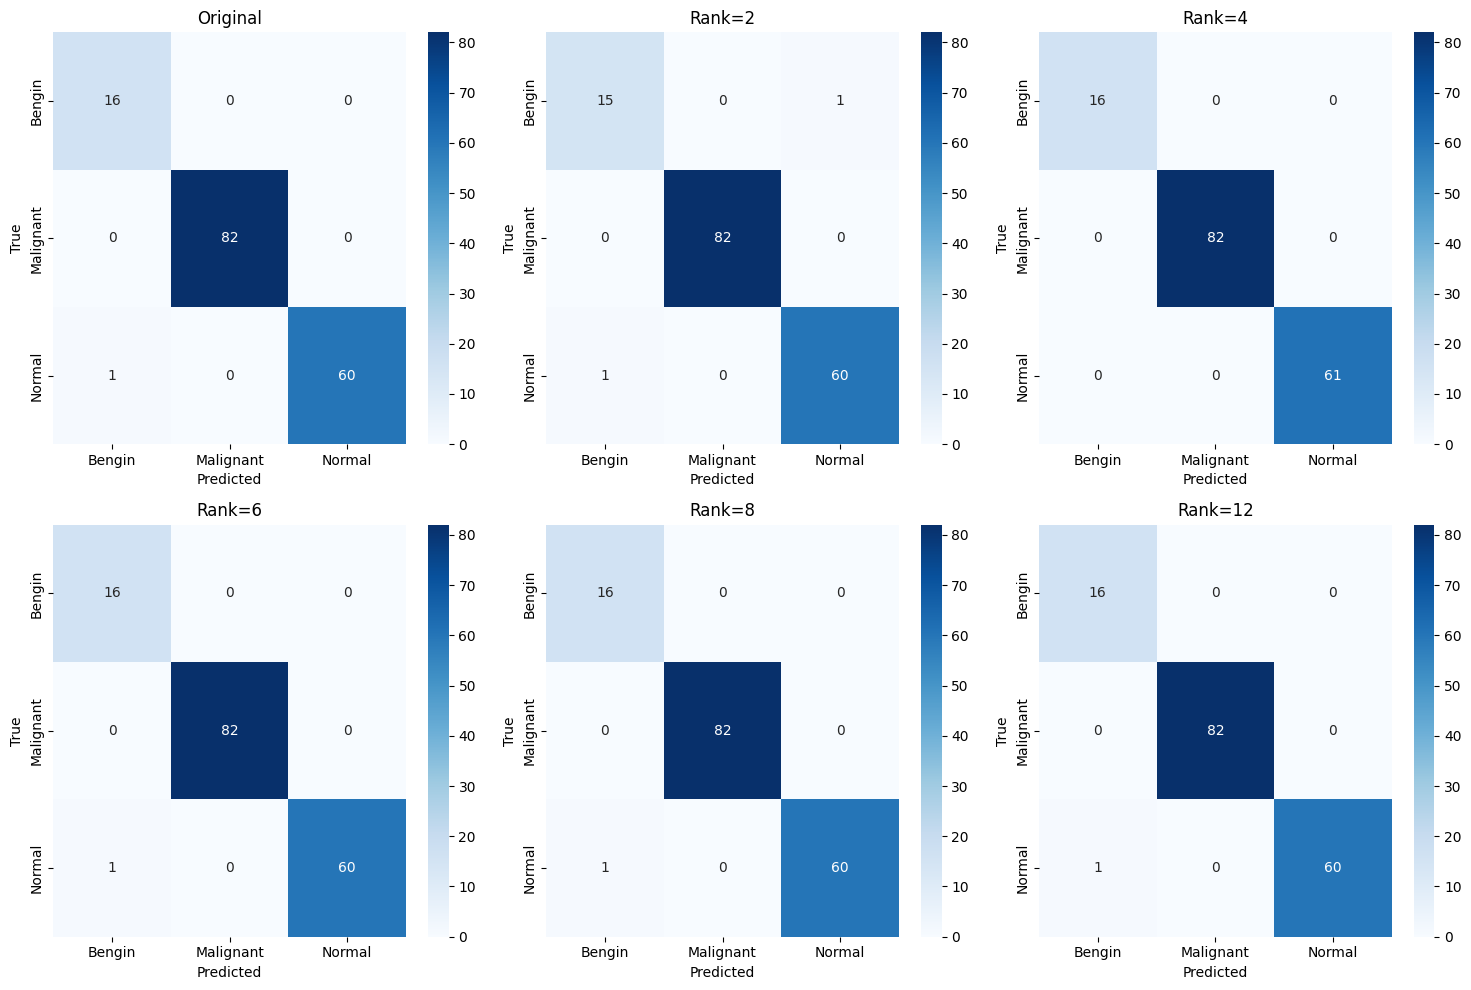

In [12]:
# ============================================================================
# RESOURCE / SIZE / METRIC COMPARISON TABLES (MULTI-RANK)
# ============================================================================
size_orig_total = orig_size_cnn + orig_size_svm + orig_size_scaler

# Build comprehensive comparison table
res_rows = [
    ("Original",
     size_orig_total, model_orig.count_params(),
     metrics_orig["feat_time"], metrics_orig["inf_time"]),
]

for rank in ranks_to_test:
    model_lr = models_by_rank[rank]
    paths_lr = paths_by_rank[rank]
    metrics_lr = metrics_by_rank[rank]
    
    size_lr_kb      = get_file_size_kb(paths_lr["cnn"])
    size_lr_gz_kb   = get_file_size_kb(paths_lr["cnn_gz"])
    size_lr_total   = (size_lr_kb +
                       get_file_size_kb(f"artifacts/svm_lowrank_r{rank}.pkl") +
                       get_file_size_kb(f"artifacts/scaler_lowrank_r{rank}.pkl"))
    size_lr_gz_total = (size_lr_gz_kb +
                        get_file_size_kb(f"artifacts/svm_lowrank_r{rank}.pkl") +
                        get_file_size_kb(f"artifacts/scaler_lowrank_r{rank}.pkl"))
    
    res_rows.append((f"Low-Rank r={rank} (.keras)",
                     size_lr_total, model_lr.count_params(),
                     metrics_lr["feat_time"], metrics_lr["inf_time"]))

res_df = resource_table(res_rows)
print("\n" + "=" * 90)
print("RESOURCE COMPARISON (ALL RANKS)")
print("=" * 90)
print(res_df.to_string(index=False))

# Comprehensive accuracy & compression comparison
print("\n" + "=" * 90)
print("ACCURACY vs COMPRESSION TRADE-OFF")
print("=" * 90)
comp_rows = [["Original", "1.00x", f"{metrics_orig['accuracy']:.4f}", 
              f"{np.mean(metrics_orig['auc_macro']):.4f}", f"{metrics_orig['feat_time']:.4f}"]]

for rank in ranks_to_test:
    model_lr = models_by_rank[rank]
    metrics_lr = metrics_by_rank[rank]
    compression = model_orig.count_params() / model_lr.count_params()
    
    comp_rows.append([
        f"Rank {rank}",
        f"{compression:.2f}x",
        f"{metrics_lr['accuracy']:.4f}",
        f"{metrics_lr['auc_macro']:.4f}",
        f"{metrics_lr['feat_time']:.4f}"
    ])

comp_df = pd.DataFrame(comp_rows, columns=["Model", "Compression", "Accuracy", "AUC (macro)", "Feature Extract Time (s)"])
print(comp_df.to_string(index=False))

# Plot: Accuracy vs Compression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy degradation
rank_vals = [None] + ranks_to_test
acc_vals = [metrics_orig['accuracy']] + [metrics_by_rank[r]['accuracy'] for r in ranks_to_test]
auc_vals = [metrics_orig['auc_macro']] + [metrics_by_rank[r]['auc_macro'] for r in ranks_to_test]

labels_plot = ["Original"] + [f"r={r}" for r in ranks_to_test]
ax1.plot(labels_plot, acc_vals, marker="o", linewidth=2.5, markersize=8, label="Accuracy", color="steelblue")
ax1.plot(labels_plot, auc_vals, marker="s", linewidth=2.5, markersize=8, label="AUC (macro)", color="darkgreen")
ax1.set_ylabel("Score"); ax1.set_title("Accuracy & AUC by Rank")
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0.8, 1.01])

# Compression ratio
comp_vals = [1.0] + [model_orig.count_params() / models_by_rank[r].count_params() for r in ranks_to_test]
ax2.bar(labels_plot, comp_vals, color=["gray"] + ["steelblue"]*len(ranks_to_test), alpha=0.7, edgecolor="black")
ax2.set_ylabel("Compression Ratio"); ax2.set_title("Parameter Compression by Rank")
ax2.grid(alpha=0.3, axis="y")
for i, v in enumerate(comp_vals):
    ax2.text(i, v + 0.05, f"{v:.2f}x", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

# Confusion matrices for all ranks
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_confusion_matrix(metrics_orig, class_names, ax=axes[0], title="Original")
for i, rank in enumerate(ranks_to_test):
    plot_confusion_matrix(metrics_by_rank[rank], class_names, ax=axes[i+1], title=f"Rank={rank}")

plt.tight_layout(); plt.show()

In [13]:
# ============================================================================
# SAVE LOW-RANK ARTEFACTS FOR ALL RANKS TO NEW FOLDER
# ============================================================================
from datetime import datetime
out_folder = f"saved_models_lowrank_multirank_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(out_folder, exist_ok=True)

print(f"Saving low-rank artefacts (all ranks) to {out_folder}/")
print("=" * 80)

for rank in ranks_to_test:
    rank_folder = os.path.join(out_folder, f"rank_{rank}")
    os.makedirs(rank_folder, exist_ok=True)
    
    paths_lr = paths_by_rank[rank]
    
    shutil.copy2(paths_lr["cnn"], os.path.join(rank_folder, f"cnn_attention_model_r{rank}.keras"))
    shutil.copy2(paths_lr["extractor"], os.path.join(rank_folder, f"feature_extractor_r{rank}.keras"))
    shutil.copy2(f"artifacts/svm_lowrank_r{rank}.pkl", os.path.join(rank_folder, f"svm_classifier_r{rank}.pkl"))
    shutil.copy2(f"artifacts/scaler_lowrank_r{rank}.pkl", os.path.join(rank_folder, f"feature_scaler_r{rank}.pkl"))
    
    # Save metrics summary
    with open(os.path.join(rank_folder, f"metrics_r{rank}.json"), "w") as f:
        metrics = metrics_by_rank[rank]
        json.dump({
            "accuracy": float(metrics["accuracy"]),
            "auc_macro": float(metrics["auc_macro"]),
            "auc_micro": float(metrics["auc_micro"]),
            "sensitivity": [float(x) for x in metrics["sensitivity"]],
            "specificity": [float(x) for x in metrics["specificity"]],
            "precision": [float(x) for x in metrics["precision"]],
            "f1": [float(x) for x in metrics["f1"]],
            "feat_time_s": float(metrics["feat_time"]),
            "inf_time_s": float(metrics["inf_time"]),
        }, f, indent=2)
    
    print(f"\nRank {rank}:")
    for fn in sorted(os.listdir(rank_folder)):
        fp = os.path.join(rank_folder, fn)
        print(f"  {fn:<45} {get_file_size_kb(fp):>10.2f} KB")
        print("\\n\" + \"=\" * 80)\nprint(f\"All artefacts saved to: {out_folder}/\")\nprint(\"=\" * 80)")


Saving low-rank artefacts (all ranks) to saved_models_lowrank_multirank_20260515_215354/

Rank 2:
  cnn_attention_model_r2.keras                    14440.57 KB
\n" + "=" * 80)
print(f"All artefacts saved to: {out_folder}/")
print("=" * 80)
  feature_extractor_r2.keras                       4842.95 KB
\n" + "=" * 80)
print(f"All artefacts saved to: {out_folder}/")
print("=" * 80)
  feature_scaler_r2.pkl                               0.98 KB
\n" + "=" * 80)
print(f"All artefacts saved to: {out_folder}/")
print("=" * 80)
  metrics_r2.json                                     0.47 KB
\n" + "=" * 80)
print(f"All artefacts saved to: {out_folder}/")
print("=" * 80)
  svm_classifier_r2.pkl                              12.42 KB
\n" + "=" * 80)
print(f"All artefacts saved to: {out_folder}/")
print("=" * 80)

Rank 4:
  cnn_attention_model_r4.keras                    14440.57 KB
\n" + "=" * 80)
print(f"All artefacts saved to: {out_folder}/")
print("=" * 80)
  feature_extractor_r4.keras             